# Testing classifiers and models

In [3]:
#=================== SETUP ===================

import os
import glob
import random
import numpy as np
import tensorflow as tf
import mimetypes

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("✅ GPU memory growth enabled")
    except RuntimeError as e:
        print(e)

tf.keras.backend.clear_session()
print("✅ Setup complete")

✅ GPU memory growth enabled
✅ Setup complete


In [4]:
# =================== PATHS & DATA SOURCES ===================

# בסיס הפרויקט
GDRIVE_PATH = os.path.expanduser('~/RealEyes/gdrive')
BASE_PROJECT_PATH = os.path.join(GDRIVE_PATH, 'deepfake_image_project', 'code')

# נתיבי דאטה
CODE_PATH = os.path.join(GDRIVE_PATH, 'code')
DATA_PATH = os.path.join(GDRIVE_PATH, 'data_set')
DATA_SPLIT_PATH = os.path.join(GDRIVE_PATH, 'data_set_split')

# תיקיית שמירה למודלים של SRM / AE
AE_SAVE_DIR = os.path.join(BASE_PROJECT_PATH, 'models', 'our_models', 'new_ae')
os.makedirs(AE_SAVE_DIR, exist_ok=True)

# נתיב בסיס לפיצול של CustomWar
DATASET_ROOT = DATA_SPLIT_PATH

# ---------------- TRAIN ----------------
train_datasets = {
    'CiFake': './datasets/cifake/train',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Train',
    'CustomWar': os.path.join(DATASET_ROOT, 'train')
}

# ---------------- VALIDATION ----------------
validation_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Validation',
    'CustomWar': os.path.join(DATASET_ROOT, 'val')
}

# ---------------- TEST ----------------
test_datasets = {
    'CiFake': './datasets/cifake/test',
    'OpenForensics': './datasets/OpenForensicsV1/Dataset/Test',
    'CustomWar': os.path.join(DATASET_ROOT, 'test')
}

print("✅ Paths & data sources ready")
print(f"GDRIVE_PATH:      {GDRIVE_PATH}")
print(f"BASE_PROJECT_PATH:{BASE_PROJECT_PATH}")
print(f"DATA_PATH:        {DATA_PATH}")
print(f"DATA_SPLIT_PATH:  {DATA_SPLIT_PATH}")
print(f"AE_SAVE_DIR:      {AE_SAVE_DIR}")

✅ Paths & data sources ready
GDRIVE_PATH:      /home/sceuser/RealEyes/gdrive
BASE_PROJECT_PATH:/home/sceuser/RealEyes/gdrive/deepfake_image_project/code
DATA_PATH:        /home/sceuser/RealEyes/gdrive/data_set
DATA_SPLIT_PATH:  /home/sceuser/RealEyes/gdrive/data_set_split
AE_SAVE_DIR:      /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae


In [5]:
# =================== HELPER: LOAD DATASET IMAGES ===================

def load_dataset_images(dataset_path, max_images=None):
    """Load image paths and labels from a dataset directory with STRICT label assignment."""
    image_paths = []
    labels = []

    # ONLY these extensions are valid
    valid_extensions = {'.jpg', '.jpeg', '.png', '.gif', '.bmp'}

    folders = os.listdir(dataset_path)

    # מיון כדי שהסדר יהיה צפוי (למרות שאנחנו מתקנים את זה למטה)
    folders.sort()

    skipped_count = 0

    for folder in folders:
        path = os.path.join(dataset_path, folder)
        if not os.path.isdir(path):
            continue

        folder_upper = folder.upper()

        if folder_upper == 'FAKE':
            current_label = 1  # תמיד 1 לזיוף
        elif folder_upper == 'REAL':
            current_label = 0  # תמיד 0 לאמיתי
        else:
            print(f"⚠️ Warning: Unknown folder name '{folder}'. Skipping.")
            continue
        # =========================================================

        for i, filename in enumerate(os.listdir(path)):
            if max_images and i >= max_images:
                break

            file_path = os.path.join(path, filename)

            # Check if it's a file
            if not os.path.isfile(file_path):
                continue

            # Check file extension
            ext = os.path.splitext(filename)[1].lower()
            if ext not in valid_extensions:
                skipped_count += 1
                continue

            # MIME type check
            mime_type, _ = mimetypes.guess_type(file_path)
            if mime_type and mime_type not in {'image/jpeg', 'image/png', 'image/gif', 'image/bmp'}:
                skipped_count += 1
                continue

            image_paths.append(file_path) # list of all the pictures - where does each pic locate
            labels.append(current_label) # list of numbres 0, 1 that match to pictures (real/fake)

    if skipped_count > 0:
        print(f"   ⚠️ Skipped {skipped_count} non-standard files in {dataset_path}")

    print(f"   ✅ Loaded {len(image_paths)} valid images from {dataset_path}")
    return image_paths, np.array(labels)

In [6]:
# =================== FULL DATA LOADING ===================

def load_all_datasets(datasets_dict, purpose_name):
    print(f"\n📦 Processing {purpose_name} Sets (FULL LOADING)...")
    print("=" * 60)

    all_paths = []
    all_labels = []

    for ds_name, ds_path in datasets_dict.items():
        print(f"   📥 Loading {ds_name} (ALL IMAGES)...")
        paths, labels = load_dataset_images(ds_path, max_images=None)
        all_paths.extend(paths)
        all_labels.extend(labels)

    return np.array(all_paths), np.array(all_labels)

print("🏗️ Building FULL Training Set...")
train_image_paths, train_labels = load_all_datasets(train_datasets, "TRAIN")

print("\n🏗️ Building FULL Validation Set...")
validation_image_paths, val_labels = load_all_datasets(validation_datasets, "VALIDATION")

print("\n🏗️ Building FULL Test Set...")
test_image_paths, test_labels = load_all_datasets(test_datasets, "TEST")

🏗️ Building FULL Training Set...

📦 Processing TRAIN Sets (FULL LOADING)...
   📥 Loading CiFake (ALL IMAGES)...
   ✅ Loaded 100000 valid images from ./datasets/cifake/train
   📥 Loading OpenForensics (ALL IMAGES)...
   ✅ Loaded 140002 valid images from ./datasets/OpenForensicsV1/Dataset/Train
   📥 Loading CustomWar (ALL IMAGES)...
   ✅ Loaded 1941 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/train

🏗️ Building FULL Validation Set...

📦 Processing VALIDATION Sets (FULL LOADING)...
   📥 Loading CiFake (ALL IMAGES)...
   ✅ Loaded 20000 valid images from ./datasets/cifake/test
   📥 Loading OpenForensics (ALL IMAGES)...
   ✅ Loaded 39428 valid images from ./datasets/OpenForensicsV1/Dataset/Validation
   📥 Loading CustomWar (ALL IMAGES)...
   ✅ Loaded 242 valid images from /home/sceuser/RealEyes/gdrive/data_set_split/val

🏗️ Building FULL Test Set...

📦 Processing TEST Sets (FULL LOADING)...
   📥 Loading CiFake (ALL IMAGES)...
   ✅ Loaded 20000 valid images from ./datasets/

In [7]:
# =================== DATASET STATISTICS ===================

print("\n" + "=" * 60)
print("📊 FINAL FULL DATASET SUMMARY")
print("=" * 60)
print(f"Train: {len(train_image_paths):,}")
print(f"Val:   {len(validation_image_paths):,}")
print(f"Test:  {len(test_image_paths):,}")
print("=" * 60)

def print_label_stats(name, labels):
    labels = np.array(labels)
    real_count = np.sum(labels == 0)
    fake_count = np.sum(labels == 1)
    print(f"{name}: REAL={real_count:,}, FAKE={fake_count:,}, TOTAL={len(labels):,}")

print_label_stats("TRAIN", train_labels)
print_label_stats("VAL", val_labels)
print_label_stats("TEST", test_labels)


📊 FINAL FULL DATASET SUMMARY
Train: 241,943
Val:   59,670
Test:  31,149
TRAIN: REAL=120,620, FAKE=121,323, TOTAL=241,943
VAL: REAL=29,864, FAKE=29,806, TOTAL=59,670
TEST: REAL=15,491, FAKE=15,658, TOTAL=31,149


In [8]:
##6# =================== SHARED PREPROCESSING ===================

IMG_SIZE_RGB = (224, 224)
IMG_SIZE_SRM = (256, 256)

BATCH_SIZE_RGB = 8
BATCH_SIZE_SRM = 32
BATCH_SIZE_HYBRID = 4

AUTOTUNE = tf.data.AUTOTUNE

def decode_rgb_image(path, label, img_size=(224, 224)):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32)
    return img, tf.cast(label, tf.float32)

def decode_rgb_image_normalized(path, label, img_size=(256, 256)):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, img_size)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.cast(label, tf.float32)

def create_rgb_dataset(image_paths, labels, batch_size=BATCH_SIZE_RGB, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    if shuffle:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)
    ds = ds.map(lambda p, y: decode_rgb_image(p, y, IMG_SIZE_RGB), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(1)
    return ds

print("✅ Shared preprocessing ready")

✅ Shared preprocessing ready


# SRM Model

In [9]:
# =================== SRM FILTERS ===================

import numpy as np

# -------------------------------
# 5x5 SRM-style filters
# -------------------------------
filters_5x5 = [
    # Filter 1: Laplacian-High Boost
    [[0, 0, -1, 0, 0],
     [0, -1, 2, -1, 0],
     [-1, 2, 4, 2, -1],
     [0, -1, 2, -1, 0],
     [0, 0, -1, 0, 0]],

    # Filter 2: Edge & Noise Enhancer
    [[-1, 2, -2, 2, -1],
     [2, -6, 8, -6, 2],
     [-2, 8, -12, 8, -2],
     [2, -6, 8, -6, 2],
     [-1, 2, -2, 2, -1]],

    # Filter 3: Diagonal Residuals
    [[2, -1, 0, -1, 2],
     [-1, -2, 3, -2, -1],
     [0, 3, 0, 3, 0],
     [-1, -2, 3, -2, -1],
     [2, -1, 0, -1, 2]],

    # Filter 4: Vertical Edge
    [[0, 0, 0, 0, 0],
     [1, -2, 1, -2, 1],
     [0, 0, 0, 0, 0],
     [-1, 2, -1, 2, -1],
     [0, 0, 0, 0, 0]],

    # Filter 5: High-Frequency / Noise Pattern
    [[1, -4, 6, -4, 1],
     [-4, 16, -24, 16, -4],
     [6, -24, 36, -24, 6],
     [-4, 16, -24, 16, -4],
     [1, -4, 6, -4, 1]],
]

# -------------------------------
# 3x3 filters to be padded into 5x5
# -------------------------------
filters_3x3_raw = [
    [[0, -1, 0],
     [-1, 4, -1],
     [0, -1, 0]],  # Basic Laplacian

    [[-1, 2, -1],
     [2, -4, 2],
     [-1, 2, -1]],  # Residual

    [[-1, -1, -1],
     [-1, 8, -1],
     [-1, -1, -1]]  # Point detection
]

def pad_3x3_to_5x5(kernels_3x3):
    padded_kernels = []
    for k in kernels_3x3:
        padded = np.pad(k, ((1, 1), (1, 1)), mode='constant', constant_values=0)
        padded_kernels.append(padded)
    return padded_kernels

filters_3x3_padded = pad_3x3_to_5x5(filters_3x3_raw)

# -------------------------------
# Final filter bank: 8 filters total
# -------------------------------
all_filters = np.array(filters_5x5 + filters_3x3_padded, dtype=np.float32)

print(f"✅ SRM filters ready: {len(all_filters)} filters, each of size 5x5")
print("all_filters shape:", all_filters.shape)

✅ SRM filters ready: 8 filters, each of size 5x5
all_filters shape: (8, 5, 5)


In [10]:
# =================== SRM FILTER FUNCTION ===================

import tensorflow as tf

# all_filters shape: (8, 5, 5)
# TF kernel shape should be: (5, 5, 1, 8)
srm_filters_tf = tf.constant(
    np.transpose(all_filters[:, :, :, np.newaxis], (1, 2, 3, 0)),
    dtype=tf.float32
)

def apply_srm_filters_tf(image):
    """
    Apply SRM filters (8 filters + tanh) to an RGB image.

    Args:
        image: Tensor of shape (H, W, 3) or (B, H, W, 3)

    Returns:
        SRM feature maps of shape:
        - (256, 256, 24) for single image
        - (B, 256, 256, 24) for batch
    """
    if len(image.shape) == 3:
        image = image[tf.newaxis, ...]
        squeeze = True
    else:
        squeeze = False

    image = tf.image.resize(image, [256, 256])
    image = tf.cast(image, tf.float32)

    channels = tf.split(image, num_or_size_splits=3, axis=-1)

    feature_maps = []
    for channel in channels:
        fm = tf.nn.conv2d(channel, srm_filters_tf, strides=1, padding='SAME')
        fm = (tf.math.tanh(fm) + 1.0) / 2.0
        feature_maps.append(fm)

    result = tf.concat(feature_maps, axis=-1)

    if squeeze:
        result = result[0]

    return result

print("✅ apply_srm_filters_tf() ready")
print("   Input: RGB image (H, W, 3) or (B, H, W, 3)")
print("   Output: SRM feature maps (256, 256, 24) or (B, 256, 256, 24)")
print("   Kernel tensor shape:", srm_filters_tf.shape)

✅ apply_srm_filters_tf() ready
   Input: RGB image (H, W, 3) or (B, H, W, 3)
   Output: SRM feature maps (256, 256, 24) or (B, 256, 256, 24)
   Kernel tensor shape: (5, 5, 1, 8)


I0000 00:00:1774959086.833208  566966 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5423 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5


In [11]:
##9# =================== SRM DATASET PIPELINE ===================

def srm_augment(srm_features, label):
    srm_features = tf.image.random_flip_left_right(srm_features)
    srm_features = tf.image.random_flip_up_down(srm_features)
    srm_features = tf.image.random_brightness(srm_features, max_delta=0.05)
    srm_features = tf.clip_by_value(srm_features, 0.0, 1.0)
    return srm_features, label

def create_srm_dataset(image_paths, labels, batch_size=BATCH_SIZE_SRM, shuffle=False, augment=False):
    def process_image(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, [256, 256])
        img = tf.cast(img, tf.float32) / 255.0

        srm_features = apply_srm_filters_tf(img)
        srm_features = tf.ensure_shape(srm_features, [256, 256, 24])

        return srm_features, tf.cast(label, tf.float32)

    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if shuffle:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)

    ds = ds.map(process_image, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(srm_augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(1)

    return ds

print("✅ SRM dataset pipeline ready")

✅ SRM dataset pipeline ready


In [12]:
# =================== PREPARE FULL SRM DATASETS ===================

print("📦 Creating FULL SRM datasets...")
print("=" * 60)

train_srm_dataset = create_srm_dataset(
    train_image_paths,
    train_labels,
    batch_size=BATCH_SIZE_SRM,
    shuffle=True,
    augment=True
)

val_srm_dataset = create_srm_dataset(
    validation_image_paths,
    val_labels,
    batch_size=BATCH_SIZE_SRM,
    shuffle=False
)

test_srm_dataset = create_srm_dataset(
    test_image_paths,
    test_labels,
    batch_size=BATCH_SIZE_SRM,
    shuffle=False
)

print(f"✅ Train SRM images: {len(train_image_paths):,}")
print(f"✅ Val SRM images:   {len(validation_image_paths):,}")
print(f"✅ Test SRM images:  {len(test_image_paths):,}")

📦 Creating FULL SRM datasets...


2026-03-31 12:11:39.807193: W external/local_xla/xla/service/gpu/llvm_gpu_backend/default/nvptx_libdevice_path.cc:41] Can't find libdevice directory ${CUDA_DIR}/nvvm/libdevice. This may result in compilation or runtime failures, if the program we try to run uses routines from libdevice.
Searched for CUDA in the following directories:
  ./cuda_sdk_lib
  ipykernel_launcher.runfiles/cuda_nvcc
  ipykernel_launcher.runfiles/cuda_nvdisasm
  ipykernel_launcher.runfiles/nvidia_nvshmem
  ipykern/cuda_nvcc
  ipykern/cuda_nvdisasm
  ipykern/nvidia_nvshmem
  
  /usr/local/cuda
  /opt/cuda
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../../../nvidia/cuda_nvcc
  /home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/tensorflow/python/platform/../../cuda
  /home/sceuser/.virtualenvs/RealEyesModels/lib/py

✅ Train SRM images: 241,943
✅ Val SRM images:   59,670
✅ Test SRM images:  31,149


In [13]:
# =================== SRM SANITY CHECK ===================

for x_batch, y_batch in train_srm_dataset.take(1):
    print("SRM batch shape:", x_batch.shape)
    print("Labels shape:", y_batch.shape)
    print("Min:", tf.reduce_min(x_batch).numpy(), "Max:", tf.reduce_max(x_batch).numpy())

SRM batch shape: (32, 256, 256, 24)
Labels shape: (32,)


2026-03-31 12:11:46.019712: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435712 bytes after encountering the first element of size 268435712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Min: 0.0 Max: 1.0


2026-03-31 12:11:46.623146: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
# =================== CLEAR GPU MEMORY ===================

import tensorflow as tf
import gc
import os

print("TensorFlow version:", tf.__version__)
print("GPUs:", tf.config.list_physical_devices('GPU'))

gc.collect()
tf.keras.backend.clear_session()

print("✅ Cleared previous session")


print("📊 GPU MEMORY STATUS:")
os.system("nvidia-smi")

TensorFlow version: 2.20.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Cleared previous session
📊 GPU MEMORY STATUS:
Tue Mar 31 12:11:52 2026       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.288.01             Driver Version: 535.288.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   72C    P0              32W /  70W |   8720MiB / 15360MiB |      0%      Default |
|         

0

In [15]:
# =================== AUTOENCODER / ENCODER ===================

from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os
import tensorflow as tf

print("🔨 Building SRM Autoencoder...")

# --------------------------------------------------
# Autoencoder input
# --------------------------------------------------
input_img = layers.Input(shape=(256, 256, 24), name="srm_input")

# ======================
# Encoder
# ======================
x = layers.Conv2D(32, (3, 3), padding="same", name="enc_conv1")(input_img)
x = layers.BatchNormalization(name="enc_bn1")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act1")(x)
x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool1")(x)   # 128x128

x = layers.Conv2D(64, (3, 3), padding="same", name="enc_conv2")(x)
x = layers.BatchNormalization(name="enc_bn2")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act2")(x)
x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool2")(x)   # 64x64

x = layers.Conv2D(128, (3, 3), padding="same", name="enc_conv3")(x)
x = layers.BatchNormalization(name="enc_bn3")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act3")(x)
x = layers.MaxPooling2D((2, 2), padding="same", name="enc_pool3")(x)   # 32x32

# רמה רביעית — latent עשיר יותר
x = layers.Conv2D(256, (3, 3), padding="same", name="enc_conv4")(x)
x = layers.BatchNormalization(name="enc_bn4")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="enc_act4")(x)
encoded = layers.MaxPooling2D((2, 2), padding="same", name="encoded_latent")(x)  # 16x16x256

# ======================
# Decoder
# ======================
x = layers.Conv2D(256, (3, 3), padding="same", name="dec_conv1")(encoded)
x = layers.BatchNormalization(name="dec_bn1_a")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act1_a")(x)
x = layers.UpSampling2D((2, 2), name="dec_up0")(x)   # 32x32

x = layers.Conv2D(128, (3, 3), padding="same", name="dec_conv2_orig")(x)
x = layers.BatchNormalization(name="dec_bn1")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act1")(x)
x = layers.UpSampling2D((2, 2), name="dec_up1")(x)   # 64x64

x = layers.Conv2D(64, (3, 3), padding="same", name="dec_conv2")(x)
x = layers.BatchNormalization(name="dec_bn2")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act2")(x)
x = layers.UpSampling2D((2, 2), name="dec_up2")(x)   # 128x128

x = layers.Conv2D(32, (3, 3), padding="same", name="dec_conv3")(x)
x = layers.BatchNormalization(name="dec_bn3")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="dec_act3")(x)
x = layers.UpSampling2D((2, 2), name="dec_up3")(x)   # 256x256

decoded = layers.Conv2D(
    24,
    (3, 3),
    activation="tanh",
    padding="same",
    name="decoder_output"
)(x)

# --------------------------------------------------
# Models
# --------------------------------------------------
autoencoder = Model(input_img, decoded, name="srm_autoencoder_24ch")
encoder = Model(input_img, encoded, name="srm_encoder_24ch")

autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="mse"
)

print("✅ Autoencoder built successfully")
print("Autoencoder output shape:", autoencoder.output_shape)
print("Encoder output shape:", encoder.output_shape)

🔨 Building SRM Autoencoder...
✅ Autoencoder built successfully
Autoencoder output shape: (None, 256, 256, 24)
Encoder output shape: (None, 16, 16, 256)


In [16]:
##14# =================== AUTOENCODER SANITY CHECK ===================

for x_batch, _ in train_srm_dataset.take(1):
    recon = autoencoder(x_batch)
    latent = encoder(x_batch)

    print("Input batch shape:   ", x_batch.shape)
    print("Reconstruction shape:", recon.shape)
    print("Latent shape:        ", latent.shape)
    break

2026-03-31 12:12:04.868689: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435456 bytes after encountering the first element of size 268435456 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size
2026-03-31 12:12:05.153415: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-03-31 12:12:07.546995: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.03GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


Input batch shape:    (32, 256, 256, 24)
Reconstruction shape: (32, 256, 256, 24)
Latent shape:         (32, 16, 16, 256)


In [17]:
# =================== PREPARE AUTOENCODER DATASETS ===================

ae_train_ds = train_srm_dataset.map(lambda x, y: (x, x), num_parallel_calls=tf.data.AUTOTUNE).prefetch(1)
ae_val_ds   = val_srm_dataset.map(lambda x, y: (x, x), num_parallel_calls=tf.data.AUTOTUNE).prefetch(1)

print("✅ Autoencoder datasets ready")

✅ Autoencoder datasets ready


In [16]:
# =================== AUTOENCODER TRAINING ===================

ae_checkpoint_path = os.path.join(AE_SAVE_DIR, "best_autoencoder_24ch.keras")

ae_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        verbose=1
    ),
    ModelCheckpoint(
        filepath=ae_checkpoint_path,
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

print("🚀 Starting full Autoencoder training...")

history_ae = autoencoder.fit(
    ae_train_ds,
    validation_data=ae_val_ds,
    epochs=30,
    callbacks=ae_callbacks,
    verbose=1
)

print("✅ Autoencoder full training complete")

🚀 Starting full Autoencoder training...
Epoch 1/30


2026-03-21 11:55:11.115003: I external/local_xla/xla/service/service.cc:163] XLA service 0x7a55dc248af0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-21 11:55:11.115035: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-21 11:55:11.529821: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-21 11:55:15.471959: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_bac

7560/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 397ms/step - loss: 0.0070

2026-03-21 12:45:42.121081: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-21 12:45:42.553150: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,32,128,128]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_tar

7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - loss: 0.0070

2026-03-21 12:57:10.965032: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[22,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-21 12:57:11.403975: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[22,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[22,32,128,128]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_tar


Epoch 1: val_loss improved from None to 0.00319, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_autoencoder_24ch.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_autoencoder_24ch.keras
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3730s 489ms/step - loss: 0.0031 - val_loss: 0.0032 - learning_rate: 5.0000e-04
Epoch 2/30
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - loss: 8.3341e-04
Epoch 2: val_loss did not improve from 0.00319
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3663s 484ms/step - loss: 0.0019 - val_loss: 0.0033 - learning_rate: 5.0000e-04
Epoch 3/30
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - loss: 7.5435e-04
Epoch 3: val_loss improved from 0.00319 to 0.00292, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_autoencoder_24ch.keras

Epoch 3: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_p

In [18]:
# =================== SAVE / LOAD ENCODER ===================

encoder_path = os.path.join(AE_SAVE_DIR, "final_encoder_24ch.keras")
autoencoder_path = os.path.join(AE_SAVE_DIR, "final_autoencoder_24ch.keras")

encoder.save(encoder_path)
autoencoder.save(autoencoder_path)

print("Encoder output shape:", encoder.output_shape)
print("✅ Encoder saved to:", encoder_path)
print("✅ Autoencoder saved to:", autoencoder_path)

Encoder output shape: (None, 16, 16, 256)
✅ Encoder saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/final_encoder_24ch.keras
✅ Autoencoder saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/final_autoencoder_24ch.keras


In [19]:
# =================== CLEAR MEMORY BEFORE CLASSIFIER ===================

import gc
gc.collect()
tf.keras.backend.clear_session()

print("✅ Memory cleared")

✅ Memory cleared


In [20]:
# =================== CNN-SRM CLASSIFIER ===================

from tensorflow.keras import layers, Model
import tensorflow as tf
import os

print("🔨 Building CNN-SRM classifier on encoder features...")

# --------------------------------------------------
# Phase 1: freeze encoder
# --------------------------------------------------
encoder.trainable = False

# classifier head input = encoder latent output
classifier_input = layers.Input(shape=encoder.output_shape[1:], name="latent_input")

x = layers.Conv2D(64, (3, 3), padding="same", name="cls_conv1")(classifier_input)
x = layers.BatchNormalization(name="cls_bn1")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="cls_act1")(x)
x = layers.Dropout(0.3, name="cls_drop1")(x)

x = layers.Conv2D(128, (3, 3), padding="same", name="cls_conv2")(x)
x = layers.BatchNormalization(name="cls_bn2")(x)
x = layers.LeakyReLU(negative_slope=0.1, name="cls_act2")(x)
x = layers.Dropout(0.3, name="cls_drop2")(x)

x = layers.GlobalAveragePooling2D(name="cls_gap")(x)
x = layers.Dense(64, activation="relu", name="cls_dense1")(x)
x = layers.Dropout(0.3, name="cls_drop3")(x)

output = layers.Dense(1, activation="sigmoid", name="prob_fake")(x)

classifier_head = Model(classifier_input, output, name="latent_classifier_head")

# full model = SRM input -> encoder -> classifier head
full_input = layers.Input(shape=(256, 256, 24), name="srm_input")
latent = encoder(full_input)
pred = classifier_head(latent)

cnn_srm = Model(full_input, pred, name="SRM_Encoder_Classifier")

cnn_srm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

print("✅ CNN-SRM classifier built successfully")
print("Full model input shape:", cnn_srm.input_shape)
print("Full model output shape:", cnn_srm.output_shape)

🔨 Building CNN-SRM classifier on encoder features...
✅ CNN-SRM classifier built successfully
Full model input shape: (None, 256, 256, 24)
Full model output shape: (None, 1)


In [21]:
# =================== CNN-SRM SANITY CHECK ===================

for x_batch, y_batch in train_srm_dataset.take(1):
    x_one = x_batch[:1]
    y_one = y_batch[:1]

    pred = cnn_srm(x_one, training=False)

    print("Input shape:", x_one.shape)
    print("Label shape:", y_one.shape)
    print("Prediction shape:", pred.shape)
    print("Prediction value:", pred.numpy())
    break

2026-03-31 12:12:59.845649: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435712 bytes after encountering the first element of size 268435712 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


Input shape: (1, 256, 256, 24)
Label shape: (1,)
Prediction shape: (1, 1)
Prediction value: [[0.50593036]]


In [35]:
# =================== CNN-SRM TRAINING - PHASE 1 ===================

phase1_checkpoint = os.path.join(AE_SAVE_DIR, "best_cnn_srm_phase1.keras")

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=4,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase1_checkpoint,
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

print("🚀 Starting CNN-SRM Phase 1 training (encoder frozen)...")

history_phase1 = cnn_srm.fit(
    train_srm_dataset,
    validation_data=val_srm_dataset,
    epochs=15,
    class_weight=srm_class_weights,
    callbacks=callbacks_phase1,
    verbose=1
)

print("✅ Phase 1 complete")

🚀 Starting CNN-SRM Phase 1 training (encoder frozen)...
Epoch 1/15


2026-03-22 18:31:10.570213: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,256,16,16]{3,2,1,0}, f32[64,256,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-22 18:31:10.749171: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,128,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,64,16,16]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target

7560/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - accuracy: 0.9683 - auc: 0.8249 - loss: 0.0846

2026-03-22 19:21:00.989584: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,64,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,256,16,16]{3,2,1,0}, f32[64,256,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-22 19:21:01.114532: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[23,128,16,16]{3,2,1,0}, u8[0]{0}) custom-call(f32[23,64,16,16]{3,2,1,0}, f32[128,64,3,3]{3,2,1,0}, f32[128]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target

7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.9683 - auc: 0.8249 - loss: 0.0846

...

7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9659 - auc: 0.8265 - loss: 0.1001
Epoch 11: val_auc did not improve from 0.66682
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3585s 474ms/step - accuracy: 0.9710 - auc: 0.9952 - loss: 0.0796 - val_accuracy: 0.5035 - val_auc: 0.5706 - val_loss: 3.4580 - learning_rate: 1.2500e-04
Epoch 12/15
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9661 - auc: 0.8259 - loss: 0.1024
Epoch 12: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 12: val_auc did not improve from 0.66682
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3596s 476ms/step - accuracy: 0.9715 - auc: 0.9952 - loss: 0.0788 - val_accuracy: 0.5031 - val_auc: 0.5894 - val_loss: 3.4197 - learning_rate: 1.2500e-04
Epoch 13/15
   1/7561 ━━━━━━━━━━━━━━━━━━━━ 1:07:21 535ms/step - accuracy: 0.0312 - auc: 0.0000e+00 - loss: 4.2434

2026-03-23 06:34:01.901820: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435968 bytes after encountering the first element of size 268435968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - accuracy: 0.9570 - auc: 0.8247 - loss: 0.1269
Epoch 13: val_auc did not improve from 0.66682
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3585s 474ms/step - accuracy: 0.9693 - auc: 0.9945 - loss: 0.0853 - val_accuracy: 0.5033 - val_auc: 0.5384 - val_loss: 3.6490 - learning_rate: 6.2500e-05
Epoch 14/15
   1/7561 ━━━━━━━━━━━━━━━━━━━━ 1:11:17 566ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 4.4713

2026-03-23 07:33:46.921908: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435968 bytes after encountering the first element of size 268435968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9576 - auc: 0.8250 - loss: 0.1315
Epoch 14: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 14: val_auc did not improve from 0.66682
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3593s 475ms/step - accuracy: 0.9698 - auc: 0.9944 - loss: 0.0855 - val_accuracy: 0.5040 - val_auc: 0.5623 - val_loss: 3.4762 - learning_rate: 6.2500e-05
Epoch 14: early stopping
Restoring model weights from the end of the best epoch: 10.
✅ Phase 1 complete


In [ ]:
# =================== CNN-SRM TRAINING - PHASE 2 ===================

print("🔓 Unfreezing top encoder layers for fine-tuning...")

encoder.trainable = True

fine_tune_from = int(len(encoder.layers) * 0.70)
for layer in encoder.layers[:fine_tune_from]:
    layer.trainable = False

print(f"Encoder layers: {len(encoder.layers)} | Frozen: {fine_tune_from} | Trainable: {len(encoder.layers) - fine_tune_from}")

cnn_srm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-6),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

phase2_checkpoint = os.path.join(AE_SAVE_DIR, "best_cnn_srm_finetuned.keras")

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_auc",
        patience=5,
        restore_best_weights=True,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc",
        factor=0.5,
        patience=2,
        mode="max",
        verbose=1
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath=phase2_checkpoint,
        monitor="val_auc",
        save_best_only=True,
        mode="max",
        verbose=1
    )
]

print("🚀 Starting CNN-SRM Phase 2 fine-tuning...")

history_phase2 = cnn_srm.fit(
    train_srm_dataset,
    validation_data=val_srm_dataset,
    epochs=20,
    class_weight=srm_class_weights,
    callbacks=callbacks_phase2,
    verbose=1
)

print("✅ Phase 2 complete")

🔓 Unfreezing top encoder layers for fine-tuning...
Encoder layers: 17 | Frozen: 11 | Trainable: 6
🚀 Starting CNN-SRM Phase 2 fine-tuning...
Epoch 1/20
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 390ms/step - accuracy: 0.6971 - auc: 0.7391 - loss: 0.8665
Epoch 1: val_auc improved from None to 0.57518, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3632s 479ms/step - accuracy: 0.8705 - auc: 0.9491 - loss: 0.3507 - val_accuracy: 0.5026 - val_auc: 0.5752 - val_loss: 3.0864 - learning_rate: 5.0000e-06
Epoch 2/20
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step - accuracy: 0.9306 - auc: 0.8085 - loss: 0.2247
Epoch 2: val_auc improved from 0.57518 to 0.62890, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/ne

2026-03-23 11:57:24.850668: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435968 bytes after encountering the first element of size 268435968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9398 - auc: 0.8141 - loss: 0.1950
Epoch 4: val_auc improved from 0.62890 to 0.65283, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras

Epoch 4: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3602s 476ms/step - accuracy: 0.9593 - auc: 0.9892 - loss: 0.1214 - val_accuracy: 0.5030 - val_auc: 0.6528 - val_loss: 2.9464 - learning_rate: 5.0000e-06
Epoch 5/20
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 386ms/step - accuracy: 0.9423 - auc: 0.8150 - loss: 0.1861
Epoch 5: val_auc did not improve from 0.65283
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3597s 476ms/step - accuracy: 0.9602 - auc: 0.9895 - loss: 0.1191 - val_accuracy: 0.5029 - val_auc: 0.6163 - val_loss: 3.0414 - learning_rate: 5.0000e-06
Epoch 6/20
   1/7561 ━━━━━━━━━━━━━━━━━━━━ 1:15:50 602ms/step - 

2026-03-23 13:57:23.600992: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435968 bytes after encountering the first element of size 268435968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 387ms/step - accuracy: 0.9436 - auc: 0.8158 - loss: 0.1773
Epoch 6: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-06.

Epoch 6: val_auc did not improve from 0.65283
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3610s 477ms/step - accuracy: 0.9598 - auc: 0.9900 - loss: 0.1176 - val_accuracy: 0.5027 - val_auc: 0.5848 - val_loss: 3.2163 - learning_rate: 5.0000e-06
Epoch 7/20
   1/7561 ━━━━━━━━━━━━━━━━━━━━ 1:12:10 573ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 5.1992

...

7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 384ms/step - accuracy: 0.8809 - auc: 0.7947 - loss: 0.3429
Epoch 12: ReduceLROnPlateau reducing learning rate to 6.24999984211172e-07.

Epoch 12: val_auc did not improve from 0.66014
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3595s 475ms/step - accuracy: 0.9342 - auc: 0.9777 - loss: 0.1848 - val_accuracy: 0.5032 - val_auc: 0.6425 - val_loss: 2.7715 - learning_rate: 1.2500e-06
Epoch 13/20
   1/7561 ━━━━━━━━━━━━━━━━━━━━ 58:05:43 28s/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 3.8134

2026-03-23 20:55:38.955409: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435968 bytes after encountering the first element of size 268435968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step - accuracy: 0.7837 - auc: 0.7530 - loss: 0.5920
Epoch 13: val_auc improved from 0.66014 to 0.69991, saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras

Epoch 13: finished saving model to /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/best_cnn_srm_finetuned.keras
7561/7561 ━━━━━━━━━━━━━━━━━━━━ 3531s 463ms/step - accuracy: 0.8866 - auc: 0.9475 - loss: 0.2982 - val_accuracy: 0.5071 - val_auc: 0.6999 - val_loss: 2.3121 - learning_rate: 6.2500e-07
Epoch 14/20
   1/7561 ━━━━━━━━━━━━━━━━━━━━ 1:07:21 535ms/step - accuracy: 0.0000e+00 - auc: 0.0000e+00 - loss: 3.7337

2026-03-23 21:54:02.515677: W tensorflow/core/kernels/data/prefetch_autotuner.cc:55] Prefetch autotuner tried to allocate 268435968 bytes after encountering the first element of size 268435968 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


7561/7561 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step - accuracy: 0.8311 - auc: 0.7736 - loss: 0.4222

In [22]:
# =================== CNN-SRM EVALUATION ===================

test_results = cnn_srm.evaluate(test_srm_dataset, verbose=1)

print("\n📊 CNN-SRM Test Results:")
for name, value in zip(cnn_srm.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

2026-03-31 12:13:17.361690: I external/local_xla/xla/service/service.cc:163] XLA service 0x744004005b30 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-31 12:13:17.361724: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-31 12:13:17.608147: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-31 12:13:20.447026: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[32,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_bac

  1/974 ━━━━━━━━━━━━━━━━━━━━ 2:14:00 8s/step - accuracy: 1.0000 - auc: 0.0000e+00 - loss: 0.6817

I0000 00:00:1774959204.183780  567032 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


971/974 ━━━━━━━━━━━━━━━━━━━━ 1s 392ms/step - accuracy: 0.7420 - auc: 0.3393 - loss: 0.6876

2026-03-31 12:19:44.796766: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66355200 exceeds 10% of free system memory.
2026-03-31 12:19:44.987411: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66355200 exceeds 10% of free system memory.
2026-03-31 12:19:44.988815: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66355200 exceeds 10% of free system memory.
2026-03-31 12:19:45.294464: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 66355200 exceeds 10% of free system memory.


973/974 ━━━━━━━━━━━━━━━━━━━━ 0s 393ms/step - accuracy: 0.7415 - auc: 0.3396 - loss: 0.6877

2026-03-31 12:19:47.115720: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,32,256,256]{3,2,1,0}, u8[0]{0}) custom-call(f32[13,24,256,256]{3,2,1,0}, f32[32,24,3,3]{3,2,1,0}, f32[32]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"operation_queue_id":"0","wait_on_operation_queues":[],"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"side_input_scale":0,"leakyrelu_alpha":0},"force_earliest_schedule":false,"reification_cost":[]}
2026-03-31 12:19:47.420696: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:546] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[13,64,128,128]{3,2,1,0}, u8[0]{0}) custom-call(f32[13,32,128,128]{3,2,1,0}, f32[64,32,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_tar

974/974 ━━━━━━━━━━━━━━━━━━━━ 393s 395ms/step - accuracy: 0.5027 - auc: 0.4997 - loss: 0.6932

📊 CNN-SRM Test Results:
loss: 0.6932
compile_metrics: 0.5027


In [23]:
# =================== CNN-SRM EVALUATION ===================

test_results = cnn_srm.evaluate(test_srm_dataset, verbose=1)

print("\n📊 CNN-SRM Test Results:")
for name, value in zip(cnn_srm.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

974/974 ━━━━━━━━━━━━━━━━━━━━ 371s 380ms/step - accuracy: 0.5027 - auc: 0.4997 - loss: 0.6932

📊 CNN-SRM Test Results:
loss: 0.6932
compile_metrics: 0.5027


In [24]:
# =================== SAVE CNN-SRM MODEL ===================

cnn_srm_path = os.path.join(AE_SAVE_DIR, "final_cnn_srm.keras")
cnn_srm.save(cnn_srm_path)

print("✅ CNN-SRM model saved to:", cnn_srm_path)

✅ CNN-SRM model saved to: /home/sceuser/RealEyes/gdrive/deepfake_image_project/code/models/our_models/new_ae/final_cnn_srm.keras


2026-03-31 12:36:43.887871: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precisi

✅ Predictions collected successfully
y_true shape: (31149,)
y_prob shape: (31149,)
First 10 probabilities: [0.5058344  0.50580674 0.50557417 0.50578046 0.5055737  0.50540483
 0.5058124  0.50584126 0.5059284  0.5058696 ]


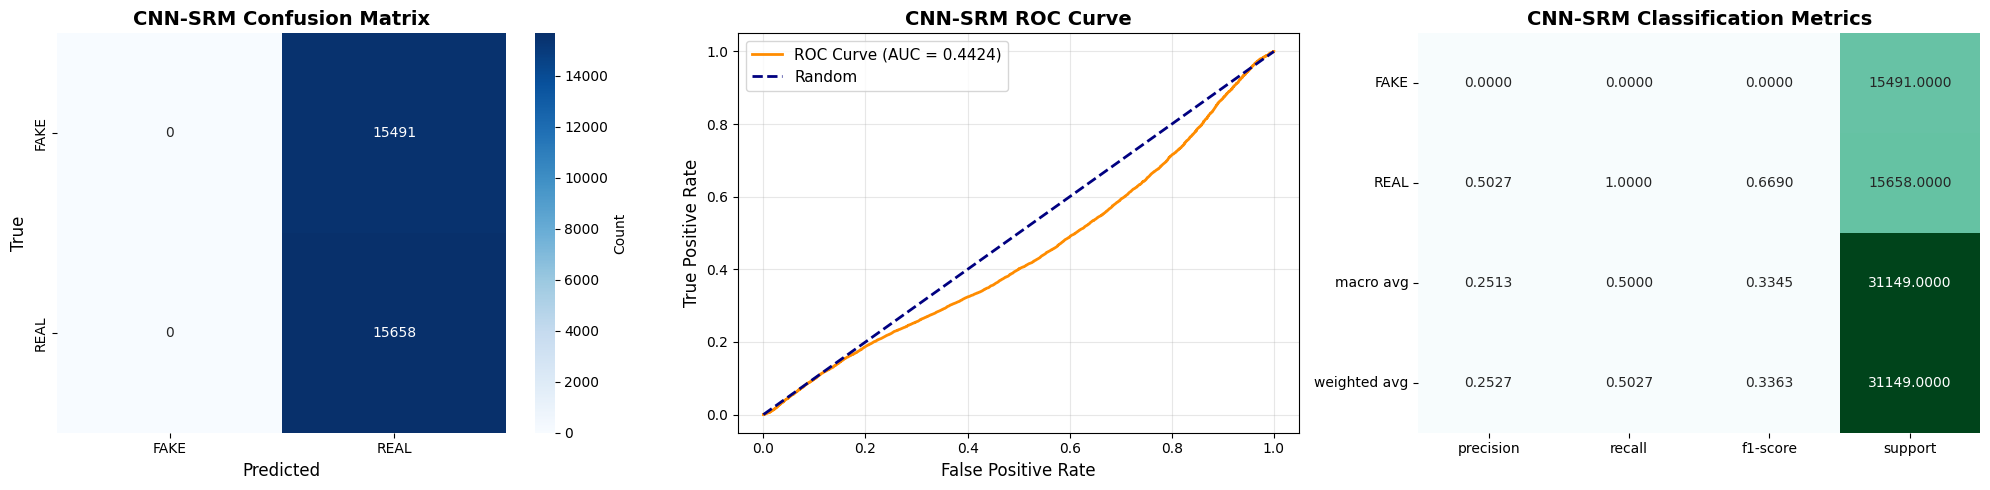


📋 CNN-SRM CLASSIFICATION REPORT
              precision    recall  f1-score   support

        FAKE     0.0000    0.0000    0.0000     15491
        REAL     0.5027    1.0000    0.6690     15658

    accuracy                         0.5027     31149
   macro avg     0.2513    0.5000    0.3345     31149
weighted avg     0.2527    0.5027    0.3363     31149


✅ CNN-SRM ROC AUC: 0.4424
✅ Visualizations complete!


/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [25]:
# ============================================================================
# CNN-SRM Visualizations (Confusion Matrix + ROC + Metrics Table)
# מותאם למחברת שלך: cnn_srm + test_srm_dataset
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc, classification_report, roc_auc_score

# ============================================================================
# 1. Collect predictions from cnn_srm on test_srm_dataset
# ============================================================================

y_true = []
y_prob = []

for x_batch, y_batch in test_srm_dataset:
    preds = cnn_srm.predict(x_batch, verbose=0).flatten()
    y_true.extend(y_batch.numpy())
    y_prob.extend(preds)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred_binary = (y_prob > 0.5).astype(int)

print("✅ Predictions collected successfully")
print("y_true shape:", y_true.shape)
print("y_prob shape:", y_prob.shape)
print("First 10 probabilities:", y_prob[:10])

# ============================================================================
# 2. Compute metrics
# ============================================================================

cm = confusion_matrix(y_true, y_pred_binary)
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

clf_report = classification_report(
    y_true,
    y_pred_binary,
    target_names=['REAL', 'FAKE'],
    output_dict=True
)

report_df = pd.DataFrame(clf_report).T
report_df = report_df.loc[
    ['FAKE', 'REAL', 'macro avg', 'weighted avg'],
    ['precision', 'recall', 'f1-score', 'support']
]

# ============================================================================
# 3. Plot: Confusion Matrix + ROC + Classification Table
# ============================================================================

plt.style.use('default')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ========== 1. Confusion Matrix ==========
ax1 = axes[0]

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=ax1,
    xticklabels=['REAL', 'FAKE'],
    yticklabels=['REAL', 'FAKE'],
    cbar_kws={'label': 'Count'}
)

ax1.set_xlabel('Predicted', fontsize=12)
ax1.set_ylabel('True', fontsize=12)
ax1.set_title('CNN-SRM Confusion Matrix', fontsize=14, fontweight='bold')

# ========== 2. ROC Curve ==========
ax2 = axes[1]

ax2.plot(
    fpr, tpr,
    color='darkorange',
    linewidth=2,
    label=f'ROC Curve (AUC = {roc_auc:.4f})'
)
ax2.plot(
    [0, 1], [0, 1],
    color='navy',
    linewidth=2,
    linestyle='--',
    label='Random'
)

ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('True Positive Rate', fontsize=12)
ax2.set_title('CNN-SRM ROC Curve', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# ========== 3. Classification Metrics Table ==========
ax3 = axes[2]

sns.heatmap(
    report_df,
    annot=True,
    cmap='Blues',
    fmt='d',
    ax=ax3,
    cbar=False
)

ax3.set_title('CNN-SRM Classification Metrics', fontsize=14, fontweight='bold')
ax3.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================================
# 4. Text report
# ============================================================================

print("\n" + "=" * 70)
print("📋 CNN-SRM CLASSIFICATION REPORT")
print("=" * 70)
print(classification_report(y_true, y_pred_binary, target_names=['REAL', 'FAKE'], digits=4))

print(f"\n✅ CNN-SRM ROC AUC: {roc_auc:.4f}")
print("✅ Visualizations complete!")

# EfficientNetB0 Model

In [30]:
import tensorflow as tf
import numpy as np
import os
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import AUC, Precision, Recall

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def decode_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_image(image, channels=3, expand_animations=False)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    return image, tf.cast(label, tf.float32)

def augment(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_flip_up_down(image)
    image = tf.image.random_brightness(image, max_delta=0.15)
    image = tf.image.random_contrast(image, lower=0.8, upper=1.2)
    image = tf.image.random_saturation(image, lower=0.85, upper=1.15)
    image = tf.image.random_hue(image, max_delta=0.05)

    # Random rotation via crop+pad trick
    image = tf.keras.layers.RandomRotation(0.05)(image, training=True)

    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

def preprocess_for_efficientnet(image, label):
    image = preprocess_input(image)
    return image, label

def build_rgb_dataset(image_paths, labels, batch_size=16, training=False):
    ds = tf.data.Dataset.from_tensor_slices((image_paths, labels))

    if training:
        ds = ds.shuffle(min(len(image_paths), 10000), reshuffle_each_iteration=True)

    ds = ds.map(decode_and_resize, num_parallel_calls=AUTOTUNE)

    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)

    ds = ds.map(preprocess_for_efficientnet, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size).prefetch(AUTOTUNE)
    return ds

train_rgb_ds = build_rgb_dataset(train_image_paths, train_labels, batch_size=BATCH_SIZE, training=True)
val_rgb_ds   = build_rgb_dataset(validation_image_paths, val_labels, batch_size=BATCH_SIZE, training=False)
test_rgb_ds  = build_rgb_dataset(test_image_paths, test_labels, batch_size=BATCH_SIZE, training=False)

print("✅ RGB datasets ready")
print("Train samples:", len(train_image_paths))
print("Val samples:", len(validation_image_paths))
print("Test samples:", len(test_image_paths))

ValueError: in user code:

    File "/tmp/ipykernel_566966/1922352470.py", line 32, in augment  *
        image = tf.keras.layers.RandomRotation(0.05)(image, training=True)
    File "/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/keras/src/layers/preprocessing/image_preprocessing/random_rotation.py", line 95, in __init__  **
        self.generator = SeedGenerator(seed)
    File "/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/keras/src/random/seed_generator.py", line 89, in __init__
        self.state = self.backend.Variable(
    File "/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/keras/src/backend/common/variables.py", line 206, in __init__
        self._initialize_with_initializer(initializer)
    File "/home/sceuser/.virtualenvs/RealEyesModels/lib/python3.12/site-packages/keras/src/backend/tensorflow/core.py", line 52, in _initialize_with_initializer
        self._initialize(lambda: initializer(self._shape, dtyp

In [8]:
def build_efficientnet_b0(input_shape=(224, 224, 3), train_base=False):
    base_model = EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = train_base

    inputs = Input(shape=input_shape, name="rgb_input")
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.30)(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.25)(x)
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.15)(x)
    outputs = Dense(1, activation="sigmoid", name="prob_fake")(x)

    model = Model(inputs, outputs, name="EfficientNetB0_Deepfake")

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
        loss=tf.keras.losses.BinaryCrossentropy(),
        metrics=[
            "accuracy",
            AUC(name="auc"),
            Precision(name="precision"),
            Recall(name="recall")
        ]
    )
    return model, base_model

eff_model, eff_base = build_efficientnet_b0(train_base=False)
eff_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "EfficientNetB0_Deepfake"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rgb_input (InputLayer)          │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prob_fake (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,668 (16.07 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [31]:
#######לעלות את זה כנראה למעלה###
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

classes_arr = np.array(train_labels)
class_weights_arr = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(classes_arr),
    y=classes_arr
)
srm_class_weights = {i: w for i, w in enumerate(class_weights_arr)}
print("SRM class weights:", srm_class_weights)

SRM class weights: {0: np.float64(1.002914110429448), 1: np.float64(0.9971027752363526)}


In [44]:
SAVE_DIR = os.path.join(GDRIVE_PATH, "code/models/efficientnet_b0")
os.makedirs(SAVE_DIR, exist_ok=True)

stage1_path = os.path.join(SAVE_DIR, "efficientnetb0_stage1_best.keras")

callbacks_stage1 = [
    ModelCheckpoint(stage1_path, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

history_stage1 = eff_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=15,
    class_weight=srm_class_weights,
    callbacks=callbacks_stage1
)

Epoch 1/8


2026-03-20 13:02:30.960041: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:31.100114: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:31.423537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:31.564504: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:02:32.473686: E external/local_xla/xla/stream_

15119/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9674 - auc: 0.8253 - loss: 0.0842 - precision: 0.9798 - recall: 0.9690

2026-03-20 13:08:02.951961: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:03.087878: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:03.403305: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:03.544230: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:08:04.417643: E external/local_xla/xla/stream_

15122/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9674 - auc: 0.8254 - loss: 0.0842 - precision: 0.9798 - recall: 0.9690

2026-03-20 13:09:36.210712: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:36.346413: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:36.659650: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:36.800166: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 13:09:37.670853: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from None to 0.71139, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras
15122/15122 ━━━━━━━━━━━━━━━━━━━━ 450s 28ms/step - accuracy: 0.9612 - auc: 0.9930 - loss: 0.1007 - precision: 0.9698 - recall: 0.9521 - val_accuracy: 0.5097 - val_auc: 0.7114 - val_loss: 2.5002 - val_precision: 0.9476 - val_recall: 0.0194 - learning_rate: 1.0000e-04
Epoch 2/8
15121/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9663 - auc: 0.8264 - loss: 0.0934 - precision: 0.9815 - recall: 0.9669
Epoch 2: val_auc improved from 0.71139 to 0.75099, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras

Epoch 2: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_stage1_best.keras
15122/15122 ━━━━━━━━━━━━━━━

In [13]:
SAVE_DIR = os.path.join(GDRIVE_PATH, "code/models/efficientnet_b0")

stage1_path = os.path.join(SAVE_DIR, "efficientnetb0_stage1_best.keras")

# טוענים את הכי טוב משלב 1
eff_model = tf.keras.models.load_model(stage1_path)

# פותחים את ה-backbone
eff_base = eff_model.get_layer("efficientnetb0")
eff_base.trainable = True

# מקפיאים את השכבות הראשונות, פותחים רק את החלק העליון
fine_tune_at = int(len(eff_base.layers) * 0.7)

for layer in eff_base.layers[:fine_tune_at]:
    layer.trainable = False

eff_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4),
    loss=tf.keras.losses.BinaryCrossentropy(),
    metrics=[
        "accuracy",
        AUC(name="auc"),
        Precision(name="precision"),
        Recall(name="recall")
    ]
)

stage2_path = os.path.join(SAVE_DIR, "efficientnetb0_finetuned_best.keras")

callbacks_stage2 = [
    ModelCheckpoint(stage2_path, monitor="val_auc", mode="max", save_best_only=True, verbose=1),
    EarlyStopping(monitor="val_auc", mode="max", patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor="val_auc", mode="max", factor=0.5, patience=3, min_lr=1e-7, verbose=1)
]

history_stage2 = eff_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=15,
    class_weight=class_weights_arr,
    callbacks=callbacks_stage2
)

Epoch 1/10


2026-03-20 14:41:22.761929: I external/local_xla/xla/service/service.cc:163] XLA service 0x728068002eb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-03-20 14:41:22.761961: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-03-20 14:41:23.502511: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-03-20 14:41:26.703064: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 91701
2026-03-20 14:41:34.551609: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:41:34.691918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time h

15120/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9405 - auc: 0.8175 - loss: 0.1541 - precision: 0.9755 - recall: 0.9420

2026-03-20 14:49:31.203423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:31.339575: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:31.653497: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:31.794241: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:49:32.681030: E external/local_xla/xla/stream_

15122/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.9405 - auc: 0.8175 - loss: 0.1541 - precision: 0.9755 - recall: 0.9420

2026-03-20 14:51:12.361309: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:12.496960: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:12.813532: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:12.954517: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 14:51:13.854932: E external/local_xla/xla/stream_


Epoch 1: val_auc improved from None to 0.76417, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras

Epoch 1: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras
15122/15122 ━━━━━━━━━━━━━━━━━━━━ 614s 38ms/step - accuracy: 0.9608 - auc: 0.9921 - loss: 0.1074 - precision: 0.9678 - recall: 0.9534 - val_accuracy: 0.5534 - val_auc: 0.7642 - val_loss: 2.3259 - val_precision: 0.9867 - val_recall: 0.1074 - learning_rate: 1.0000e-05
Epoch 2/10
15122/15122 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9601 - auc: 0.8250 - loss: 0.1174 - precision: 0.9827 - recall: 0.9624
Epoch 2: val_auc improved from 0.76417 to 0.77482, saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras

Epoch 2: finished saving model to /home/sceuser/RealEyes/gdrive/code/models/efficientnet_b0/efficientnetb0_finetuned_best.keras
15122/15122 ━━

In [14]:
best_eff_model = tf.keras.models.load_model(stage2_path)

test_results = best_eff_model.evaluate(test_rgb_ds, verbose=1)
print("\n✅ EfficientNetB0 Test Results:")
for name, value in zip(best_eff_model.metrics_names, test_results):
    print(f"{name}: {value:.4f}")

1946/1947 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.2939 - auc: 0.5129 - loss: 4.3495 - precision: 0.9920 - recall: 0.0593

2026-03-20 16:59:49.138345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:49.277292: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:49.598112: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:49.738893: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-20 16:59:50.607157: E external/local_xla/xla/stream_

1947/1947 ━━━━━━━━━━━━━━━━━━━━ 63s 26ms/step - accuracy: 0.5811 - auc: 0.7727 - loss: 2.3924 - precision: 0.9494 - recall: 0.1761

✅ EfficientNetB0 Test Results:
loss: 2.3924
compile_metrics: 0.5811


In [16]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
import numpy as np

y_true = []
y_prob = []

for x_batch, y_batch in test_rgb_ds:
    probs = best_eff_model.predict(x_batch, verbose=0).flatten()
    y_true.extend(y_batch.numpy())
    y_prob.extend(probs)

y_true = np.array(y_true).astype(int)
y_prob = np.array(y_prob)
y_pred = (y_prob > 0.2).astype(int)

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred, digits=4))

print("\nROC AUC:")
print(roc_auc_score(y_true, y_prob))

Confusion Matrix:
[[15223   268]
 [11788  3870]]

Classification Report:
              precision    recall  f1-score   support

           0     0.5636    0.9827    0.7163     15491
           1     0.9352    0.2472    0.3910     15658

    accuracy                         0.6130     31149
   macro avg     0.7494    0.6149    0.5537     31149
weighted avg     0.7504    0.6130    0.5528     31149


ROC AUC:
0.8796754503471947


2026-03-20 17:14:24.764640: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
